# Facturar

La idea de este proyecto es automatizar la facturación de cualquiera que tenga que usar el aplicativo Mis Comprobantes en Línea de AFIP. En resumidas cuentas, el usuario tiene que poder facturar solo con una lista en excel de sus ventas y el programa se tiene que encargar de subir una por una todas sus ventas. Los pasos necesarios para esto son varios, pero tenemos que:

    - Llegar a la página de Mis comprobantes en Línea
    - Pasar cada página del aplicativo con la información de cada factura
    - Facturar

Para llegar a la página de Mis Comprobantes necesitamos cuit y contraseña de afip. Luego llegar al aplicativo.

Pasar cada página es más complicado. Esto porque cada página tiene varios elementos que dependen de la venta que se efectúe. Esto dificulta la personalización. Pero en general, cada página tiene cierta información a completar, y botones para continuar.

## Conceptos clave

- Facturación
- Aplicativo
- Mis Comprobantes en Línea
- Facturar
- Lista en excel
- Ventas
- Subir
- Página
- Información de factura
- Llenar
- Elementos
- Información a completar
- Botones

### Árbol

- Aplicativo MCL
  - Páginas
    + Avanzar de página
    + Seleccionar los botones
    - Información propia
      + Leer la información
    - Elementos a completar
        +  Encontrar los elementos
        +  Cargarles la información


### Secciones

Página 1 → Punto de Ventas y Tipos de Comprobantes habilitados para impresión

  - Puntos de Ventas a utilizar (desplegable) → Depende del cliente
  - Tipo de Comprobante (desplegable) → Depende de lo que pueda hacer el cliente. Elige factura por defecto una vez que se eligió lo de arriba

Página 2 → Datos de emisión

  - Fecha del Comprobante → Fecha DD/MM/AAAA se puede imputar manual. Tiene un calendario
  - Conceptos a incluir (desplegable) → Son 3, pero depende el que eligas cambia una banda lo otro
    - Productos
      - Actividad (desplegable) → Según cliente puede tener una sola o más
    - Servicios | Productos y Servicios
      - Desde → Fecha DD/MM/AAAA se puede imputar manual. Tiene un calendario
      - Hasta → Fecha DD/MM/AAAA se puede imputar manual. Tiene un calendario
      - Vto. para el Pago → Fecha DD/MM/AAAA se puede imputar manual. Tiene un calendario (no sé con qué llenarlo)
      - Actividad (desplegable) → Según cliente puede tener una sola o más

Página 3 → 



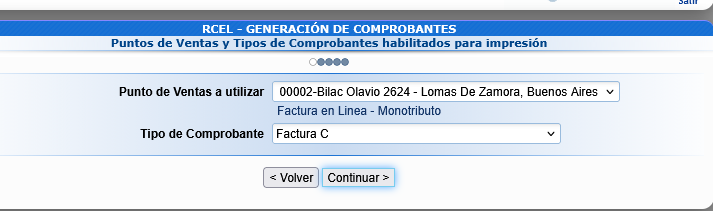

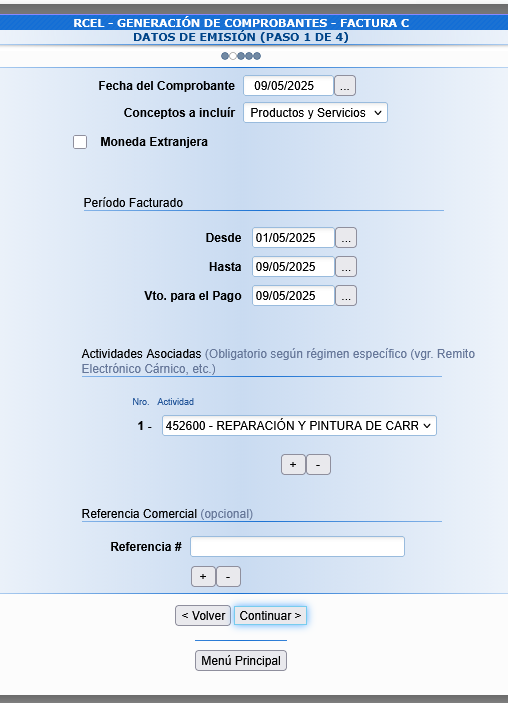

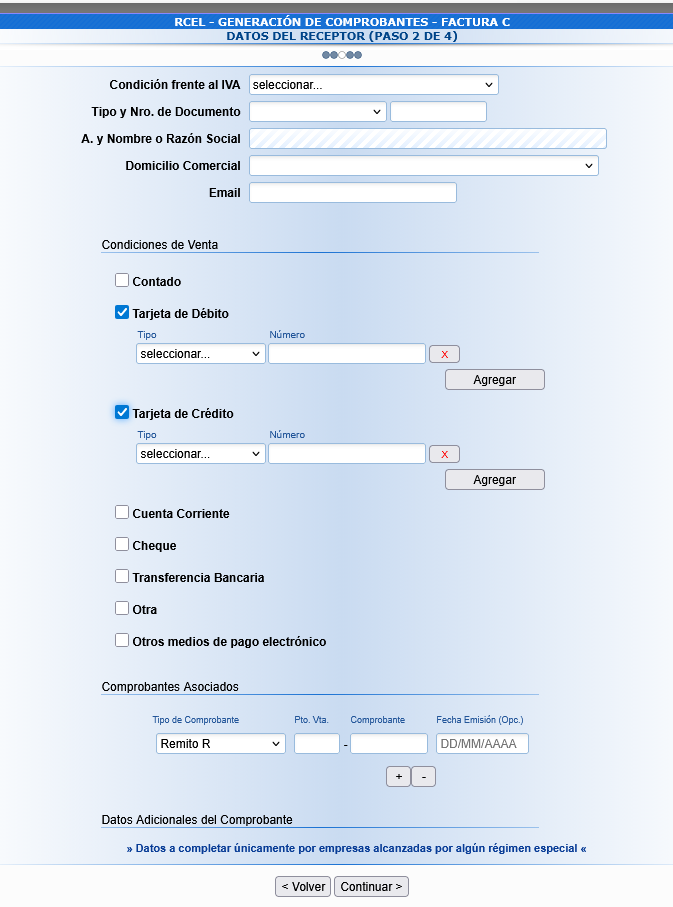

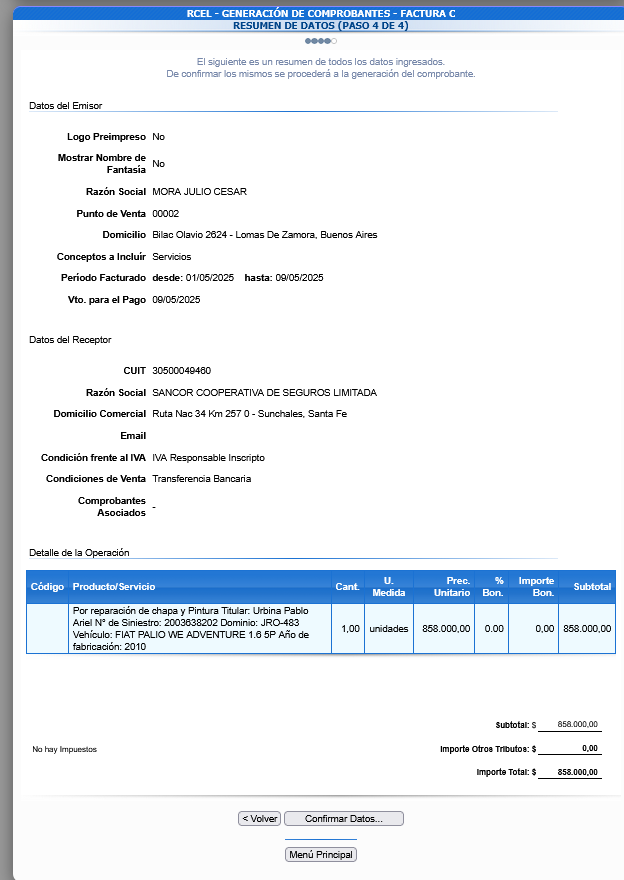

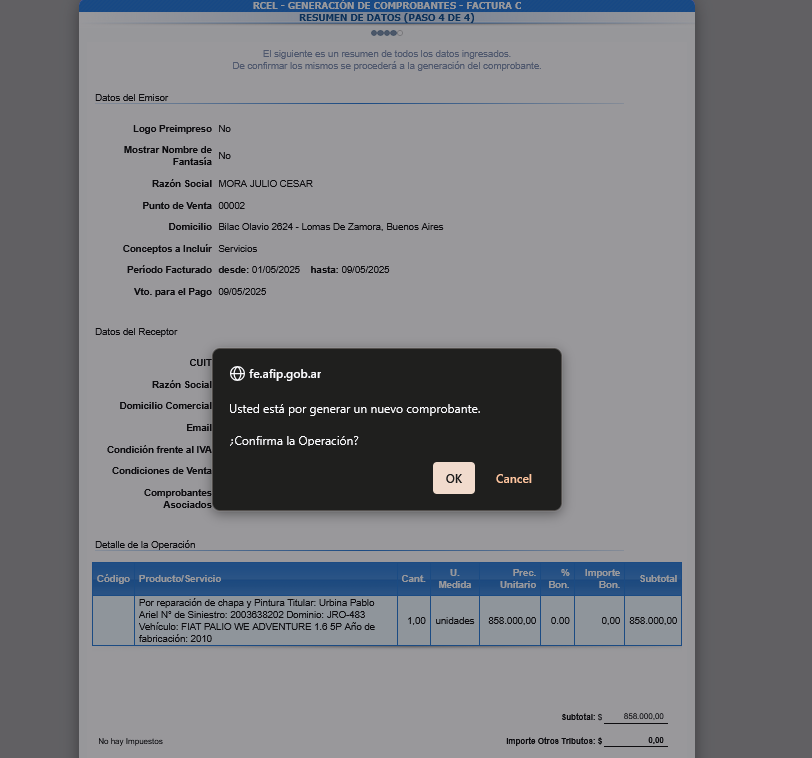

### Hay varios tipos de botones:

    - Desplegables
      - Permiten usar Select y básicamente es por índice
    - Input
      - Hay que localizarlos y agregarles su input correspondiente
    - En lista
        - Hay varios y hay que elegir mediante un click alguno de esos
    - Interactivos
      - Botones
        - Volver, Continuar, Menú Principal
      - Casillas
        - Usualmente las casillas abren más campos a completar
      


In [ ]:
from selenium                                import webdriver                  # webdriver sirve para agarrar el navegador
from selenium.common.exceptions              import ElementClickInterceptedException
from selenium.common.exceptions              import TimeoutException
from selenium.webdriver.common.by            import By                         # By sirve para filtrar elementos
from selenium.webdriver.common.action_chains import ActionChains               # Para realizar cadenas de comandos de teclado
from selenium.webdriver.common.keys          import Keys                       # Para importar las teclas del teclado
from selenium.webdriver.support              import expected_conditions as EC  # Para esperar los elementos
from selenium.webdriver.support.ui           import Select                     # Para elegir de desplegables
from selenium.webdriver.support.ui           import WebDriverWait              # Para que espere mientras carga la página 
from sqlalchemy                              import create_engine              # Para interactuar con la base de datos
from estudio_contable.common.funciones_pub import afip_login, afip_elegir_aplicativo




def cel_ingreso(user, password):
    driver = afip_login(user, password)
    afip_elegir_aplicativo(driver, 1)
    return driver

driver = cel_ingreso(USER, PASSWORD)

In [ ]:
from selenium.common.exceptions import StaleElementReferenceException
import time
# class Desplegable(object):
#     TIMEOUT = 10

#     def __init__(self, driver, locator, options=None):
#         self.driver      = driver
#         self.locator     = locator
#         self.options     = options or {}
#         self.desplegable = Select(WebDriverWait(driver, self.TIMEOUT).until(EC.element_to_be_clickable(self.locator)))

#     def seleccionar_indice(self, index):
#         self.desplegable.select_by_index(index)

class Elemento(object):
    TIMEOUT = 10
    RETRY_DELAY = 0.5
    MAX_RETRIES = 3

    def __init__(self, driver, locator):
        self.driver = driver
        self.locator = locator
        self.object = None
        self.get_object_with_retries()

    def _get_object(self):
        """A implementar"""
        raise NotImplementedError('Esto lo tiene que implementar cada subclase')
    
    def _get_object_with_retries(self):
        for _ in range(self.MAX_RETRIES):
            try:
                self.object = self._get_object()
                return
            except (TimeoutException, StaleElementReferenceException):
                time.sleep(self.RETRY_DELAY)
            raise TimeoutException(f'No se encontró el objeto después de {self.MAX_RETRIES} intentos.')
    
    def _ensure_fresh(self):
        """Refrescar el objeto por si no está clickeable"""
        try:
            _ = self.object.tag_name
        except StaleElementReferenceException:
            self._get_object_with_retries()


class Desplegable(Elemento):

    def __init__(self, options):
        super().__init__(self.driver, self.locator)
        self.options = options or {}
        self.object = self._get_object()
        
    def _get_object(self):
        elemento = WebDriverWait(self.driver, self.TIMEOUT).until(EC.element_to_be_clickable(self.locator))
        return Select(elemento)
    
    def seleccionar_indice(self, index):
        self._ensure_fresh()
        self.object.select_by_index(index)





class Desplegable_old(object):
    TIMEOUT = 10
    RETRY_DELAY = 0.5
    MAX_RETRIES = 3

    def __init__(self, driver, locator, options=None):
        self.driver = driver
        self.locator = locator
        self.options = options or {}
        self._get_selector()             # Si esto no es una función, no lo puede volver a intentar agarrar después

    def _get_selector(self):
        self.desplegable = Select(WebDriverWait(self.driver, self.TIMEOUT).until(EC.element_to_be_clickable(self.locator)))

    def seleccionar_indice(self, index):
        for _ in range(self.MAX_RETRIES):
            try:
                self.desplegable.select_by_index(index)
                return
            except StaleElementReferenceException:
                time.sleep(self.RETRY_DELAY)
                self._get_selector()
        raise StaleElementReferenceException(f'No se pudo seleccionar el valor {index} después de {self.MAX_RETRIES} intentos.')

    



# Desplegables
# class PuntoDeVenta(Desplegable):
#     PUNTOS_DE_VENTA = {
#         'seleccionar' :       0,
#         'PuntoDeVenta1'     : 1,
#         'PuntoDeVenta2'     : 2,
#         'PuntoDeVenta3'     : 3,
#         'PuntoDeVenta4'     : 4,
#         'PuntoDeVenta5'     : 5
#     }
#     def __init__(self, driver, puntos_de_venta=None):
#         if puntos_de_venta:
#             self.options = puntos_de_venta
#         else:
#             self.options = self.PUNTOS_DE_VENTA
#         locator = (By.NAME, 'idIVAReceptor')
#         super().__init__(driver, locator, self.options)

class TipoComprobantesRI(Desplegable):
    TIPO_COMPROBANTE_RI = {
        'Factura A'         : 0,
        'Nota de Débito A'  : 1,
        'Nota de Crédito A' : 2,
        'Recibo A'          : 3,
        'Factura B'         : 4,
        'Nota de Débito B'  : 5,
        'Nota de Crédito B' : 6,
        'Recibo B'          : 7,
        'Factura T'         : 8,
        'Nota de Débito T'  : 9,
        'Nota de Crédito T' : 10
    }
    def __init__(self, driver):
        locator = (By.NAME, 'universoComprobante')
        super().__init__(driver, locator, self.TIPO_COMPROBANTE_RI)


class CondicionIvaFA(Desplegable):
    OPCIONES = {
    'seleccionar' : 0,
    'IVA Responsable Inscripto'                         : 1,
    'Responsable Monotributo'                           : 2,
    'Monotributista Social'                             : 3,
    'Monotributista Trabajador Independiente Promovido' : 4
    }

    def __init__(self, driver):
        locator = (By.NAME, 'idIVAReceptor')
        super().__init__(driver, locator, self.OPCIONES)



In [125]:
import time

PUNTO_DE_VENTA = {
    'seleccionar'    : 0,
    'La Habana 1383' : 1,
    'La Habana 1370' : 2
}
pdv = 'La Habana 1370'
locator_punto_de_venta = (By.NAME, 'puntoDeVenta')
punto_de_venta = Desplegable(driver, locator_punto_de_venta, PUNTO_DE_VENTA)
punto_de_venta.seleccionar_indice(punto_de_venta.options[pdv])


tipo_comp = 'Factura B'
tipo_comprobante_ri = TipoComprobantesRI(driver)
tipo_comprobante_ri.seleccionar_indice(tipo_comprobante_ri.options[tipo_comp])



TypeError: Elemento.__init__() takes 3 positional arguments but 4 were given

In [80]:
TIMEOUT = 10

# Orden lineal

## Lista de opciones por botón
EMPRESAS = {
    'Espacio Tortugas' : 0,
    'Lopez Leo'        : 1
}

empresa = 'Espacio Tortugas'
locator_empresas = (By.CLASS_NAME, 'btn_empresa')
lista_empresas = WebDriverWait(driver, 10).until(EC.presence_of_all_elements_located(locator_empresas))
btn_empresa = lista_empresas[EMPRESAS[empresa]]
btn_empresa.click()

PAG_1 = {
    'Generar Comprobantes' : 0,
    'Consultas'            : 1
}

accion_p1 = 'Generar Comprobantes'
#accion_p1 = 'Consultas'
locator_acciones_p1 = (By.CLASS_NAME, 'ui-button')
lista_acciones_p1 = WebDriverWait(driver, 10).until(EC.presence_of_all_elements_located(locator_acciones_p1))
btn_accion = lista_acciones_p1[PAG_1[accion_p1]]
btn_accion.click()

## Lista de opciones desplegable
PUNTO_DE_VENTA = {
    'seleccionar'    : 0,
    'La Habana 1383' : 1,
    'La Habana 1370' : 2
}

punto_de_venta = 'La Habana 1383'
locator_punto_de_venta = (By.NAME, 'puntoDeVenta')
selector_punto_de_venta = Select(WebDriverWait(driver, 10).until(EC.presence_of_element_located(locator_punto_de_venta)))
selector_punto_de_venta.select_by_index(PUNTO_DE_VENTA[punto_de_venta])

TIPO_COMPROBANTE = {
    'Factura A'         : 0,
    'Nota de Débito A'  : 1,
    'Nota de Crédito A' : 2,
    'Recibo A'          : 3,
    'Factura B'         : 4,
    'Nota de Débito B'  : 5,
    'Nota de Crédito B' : 6,
    'Recibo B'          : 7,
    'Factura T'         : 8,
    'Nota de Débito T'  : 9,
    'Nota de Crédito T' : 10
}

tipo_comprobante = 'Factura A'
locator_tipo_comprobante = (By.NAME, 'universoComprobante')
selector_tipo_comprobante = Select(WebDriverWait(driver, 10).until(EC.presence_of_element_located(locator_tipo_comprobante)))
selector_tipo_comprobante.select_by_index(TIPO_COMPROBANTE[tipo_comprobante])

In [82]:
# Botones de interacción general: Volver, Continuar, Menú Principal

btn_volver                = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.XPATH, "//input[@value='< Volver']")))
btn_continuar             = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.XPATH, "//input[@value='Continuar >']")))
#btn_menu_ppal             = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.XPATH, "//input[@value='Menú Principal']")))

# Casillas de interacción
#casilla_moneda_extranjera = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.XPATH, "//input[@name='monedaExtranjera']")))
#casilla_pago_misma_moneda = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.XPATH, "//input[@id='cancelacionMonedaExtranjera']")))

btn_continuar.click()

In [ ]:

# BOTONES_DE_FECHAS = {
#         'Fecha del Comprobante' : 'fechaEmisionComprobante',
#         'Desde'                 : 'periodoFacturadoDesde',
#         'Hasta'                 : 'periodoFacturadoHasta',
#         'Vto. para el Pago'     : 'vencimientoPago'
# }

valor = '10/55/2025'
btn_fecha_comprobante      = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.NAME, 'fechaEmisionComprobante')))
btn_fecha_desde            = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.NAME, 'periodoFacturadoDesde')))
btn_fecha_hasta            = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.NAME, 'periodoFacturadoHasta')))
btn_fecha_vencimiento_pago = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.NAME, 'vencimientoPago')))


CONCEPTOS_A_INCLUIR = {
    'seleccionar'           : 0,
    'Productos'             : 1,
    'Servicios'             : 2,
    'Productos y Servicios' : 3
}

concepto = 'Productos'
locator_concepto = (By.NAME, 'idConcepto')
selector_concepto = Select(WebDriverWait(driver, 10).until(EC.presence_of_element_located(locator_concepto)))
selector_concepto.select_by_index(CONCEPTOS_A_INCLUIR[concepto])

casilla_moneda_extranjera = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.XPATH, "//input[@name='monedaExtranjera']")))
casilla_pago_misma_moneda = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.XPATH, "//input[@id='cancelacionMonedaExtranjera']")))
# if pago_misma_moneda no se puede cambiar el input de Tipo de Cambio



In [ ]:
MONEDAS = {
    'seleccionar' : 0,
    'Dólar Estadounidense' : 15,
    'Dólar Libre EEUU'     : 16
}

# Dólar elegido por default | capaz poner un input
moneda = 'Dólar Estadounidense'
locator_moneda = (By.NAME, 'moneda')
selector_moneda = Select(WebDriverWait(driver, 10).until(EC.presence_of_element_located(locator_moneda)))
selector_moneda.select_by_index(MONEDAS[moneda])

tc = 1136.00
btn_tipo_de_cambio = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.NAME, 'tipoCambio')))
btn_tipo_de_cambio.clear()
btn_tipo_de_cambio.send_keys(tc)

In [ ]:
def elegir_en_desplegable(driver, locator, value):
    TIMEOUT = 10
    selector = Select(WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located(locator)))
    selector.select_by_index(value)


# Depende del cliente. Gralmente calculo tendrá una
ACTIVIDADES = {
    'seleccionar'     : 0,
    'Fast Food'       : 1,
    'Expendio Comida' : 2,
    'Alquiler'        : 3,
}

actividad = 'Fast Food'
locator_actividades = (By.NAME, 'actiAsociadaId')
elegir_en_desplegable(driver, locator_actividades, ACTIVIDADES[actividad])


# Referencia Comercial (opcional)
btn_referencia = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.NAME, 'refComEmisor')))





In [67]:
AGREGAR_O_RESTAR_ELEMENTOS = {
    'Agregar' : '+',
    'Restar'  : '-',
    'Primero'  : 0,
    'Segundo' : 1
}

elemento = 'Primero'
modo = 'Restar'
locator_agregar_cosas = (By.XPATH, f"(//input[@value='{AGREGAR_O_RESTAR_ELEMENTOS[modo]}'])")
lista_botones_agregar_cosas = WebDriverWait(driver, 10).until(EC.presence_of_all_elements_located(locator_agregar_cosas))
btn_agregar_act = lista_botones_agregar_cosas[AGREGAR_O_RESTAR_ELEMENTOS[elemento]]
btn_agregar_act.click()

In [59]:
btn_agregar_act = WebDriverWait(driver, TIMEOUT).until(EC.presence_of_element_located((By.XPATH, "//input[@value='+']")))
btn_agregar_act.click()